# TFG — Visualización de Datos y Storytelling Digital
## Descarga, Exploración y Análisis de Calidad del Dataset


---
## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

---
## 1. Carga del dataset


In [ ]:
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')

In [6]:
df = pd.read_csv(r'C:\Users\luisb\OneDrive\Escritorio\trabajofinalseguridad\tfg-visualizacion-datos-marketing\online_advertising_performance_data.csv', encoding='ISO-8859-1')

print(f'Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas')

Dataset cargado: 15,408 filas y 14 columnas


---
## 2. Exploración inicial

In [7]:
#Primeras filas
display(df.head(5))

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
0,April,1,camp 1,High,160 x 600,abc,4,0.01,0,0.00,0,0.00,NaN,NaN
1,April,1,camp 1,High,160 x 600,def,20170,26.78,158,28.97,23,1972.46,NaN,NaN
2,April,1,camp 1,High,160 x 600,ghi,14701,27.63,158,28.98,78,2497.26,NaN,NaN
3,April,1,camp 1,High,160 x 600,mno,171259,216.88,1796,329.45,617,24625.32,NaN,NaN
4,April,1,camp 1,Low,160 x 600,def,552,0.07,1,0.18,0,0.00,NaN,NaN


In [8]:
#Últimas filas
df.tail(5)

,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
15403,April,1,camp 1,Low,160 x 600,ghi,16,0.02,0,0.00,0,0.00,NaN,NaN
15404,April,1,camp 1,Low,160 x 600,mno,2234,0.40,10,1.83,3,101.75,NaN,NaN
15405,June,29,camp 1,High,800 x 250,ghi,1,0.02,0,0.00,0,0.00,NaN,NaN
15406,June,29,camp 1,High,800 x 250,mno,4,0.01,0,0.00,0,0.00,NaN,NaN
15407,June,29,camp 3,High,240 x 400,def,1209,0.32,2,0.11,3,110.42,NaN,NaN


In [9]:
#Tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15408 entries, 0 to 15407
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   month                    15408 non-null  object 
 1   day                      15408 non-null  int64  
 2   campaign_number          15408 non-null  object 
 3   user_engagement          15408 non-null  object 
 4   banner                   15408 non-null  object 
 5   placement                14995 non-null  object 
 6   displays                 15408 non-null  int64  
 7   cost                     15408 non-null  float64
 8   clicks                   15408 non-null  int64  
 9   revenue                  15408 non-null  float64
 10  post_click_conversions   15408 non-null  int64  
 11  post_click_sales_amount  15408 non-null  float64
 12  Unnamed: 12              0 non-null      float64
 13  Unnamed: 13              0 non-null      float64
dtypes: float64(5), int64(4

In [10]:
#Estadísticas descriptivas de las columnas numéricas
df.describe()

,day,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
count,15408.00,15408.00,15408.00,15408.00,15408.00,15408.00,15408.00,0.00,0.00
mean,15.52,15512.57,11.37,161.79,17.93,42.30,2123.29,NaN,NaN
std,8.74,44392.39,45.37,728.28,96.78,213.69,10523.03,NaN,NaN
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
25%,8.00,78.00,0.02,0.00,0.00,0.00,0.00,NaN,NaN
50%,15.00,1182.00,0.34,6.00,0.48,0.00,0.00,NaN,NaN
75%,23.00,8960.25,2.54,53.00,3.84,3.00,163.35,NaN,NaN
max,31.00,455986.00,556.70,14566.00,2096.21,3369.00,199930.32,NaN,NaN


In [11]:
#Estadísticas descriptivas de las columnas categóricas
df.describe(include='object')

,month,campaign_number,user_engagement,banner,placement
count,15408,15408,15408,15408,14995
unique,3,3,3,8,5
top,April,camp 3,Medium,728 x 90,mno
freq,6269,6917,5489,3142,4501


---
## 3. Análisis de calidad de datos

In [12]:
#Valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% sobre el total': porcentaje_nulos
})

print('=== VALORES NULOS ===')
print(resumen_nulos)

=== VALORES NULOS ===
                         Nulos  % sobre el total
month                        0              0.00
day                          0              0.00
campaign_number              0              0.00
user_engagement              0              0.00
banner                       0              0.00
placement                  413              2.68
displays                     0              0.00
cost                         0              0.00
clicks                       0              0.00
revenue                      0              0.00
post_click_conversions       0              0.00
post_click_sales_amount      0              0.00
Unnamed: 12              15408            100.00
Unnamed: 13              15408            100.00


In [15]:
#Filas duplicadas
duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {duplicados}')

if duplicados > 0:
    display(df[df.duplicated(keep=False)].head(5))

Filas duplicadas: 5


,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
5,April,1,camp 1,Low,160 x 600,ghi,16,0.02,0,0.00,0,0.00,NaN,NaN
6,April,1,camp 1,Low,160 x 600,mno,2234,0.40,10,1.83,3,101.75,NaN,NaN
15196,June,29,camp 1,High,800 x 250,ghi,1,0.02,0,0.00,0,0.00,NaN,NaN
15197,June,29,camp 1,High,800 x 250,mno,4,0.01,0,0.00,0,0.00,NaN,NaN
15198,June,29,camp 3,High,240 x 400,def,1209,0.32,2,0.11,3,110.42,NaN,NaN


Columnas categóricas: ['month', 'campaign_number', 'user_engagement', 'banner', 'placement']

--- month (3 valores únicos) ---
month
April    6269
May      4705
June     4434

--- campaign_number (3 valores únicos) ---
campaign_number
camp 3    6917
camp 1    6877
camp 2    1614

--- user_engagement (3 valores únicos) ---
user_engagement
Medium    5489
Low       5035
High      4884

--- banner (8 valores únicos) ---
banner
728 x 90     3142
300 x 250    2820
240 x 400    2425
670 x 90     2352
468 x 60     1899
160 x 600    1805
580 x 400     606
800 x 250     359

--- placement (5 valores únicos) ---
placement
mno    4501
def    3538
ghi    3484
jkl    2504
abc     968



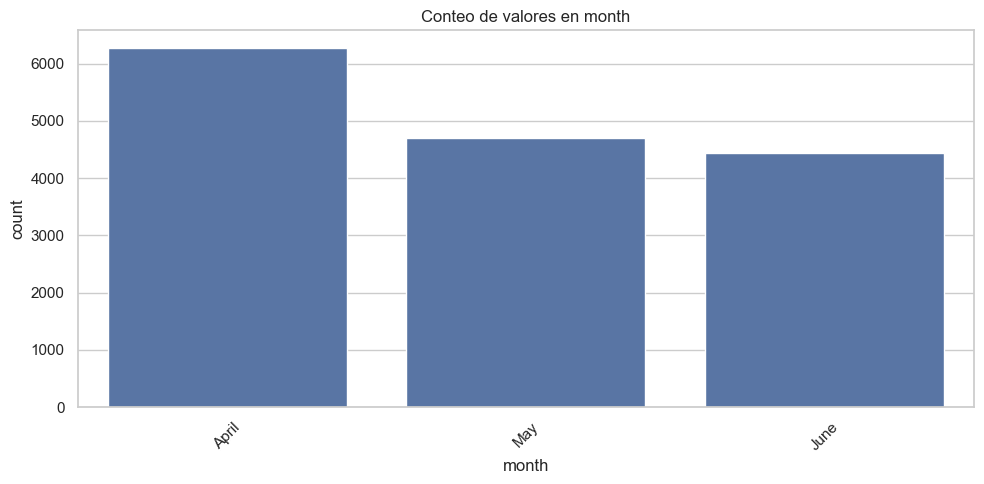

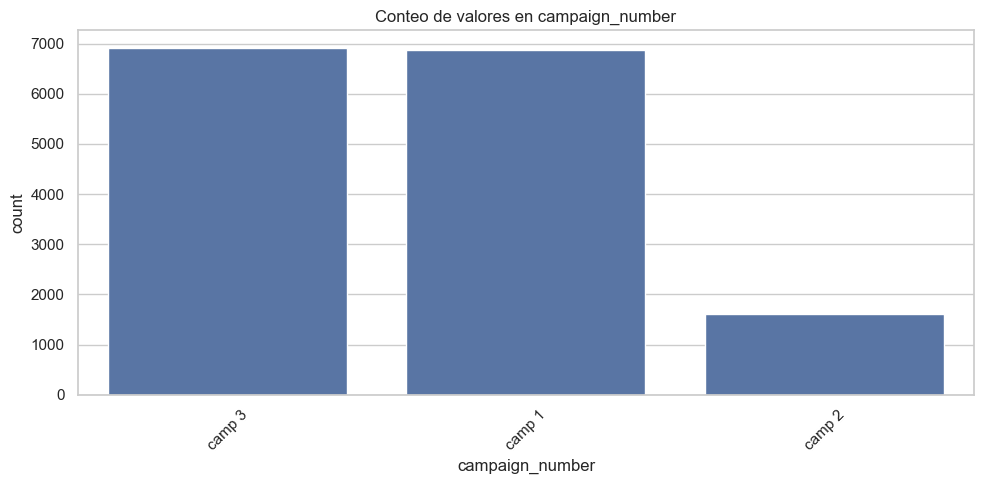

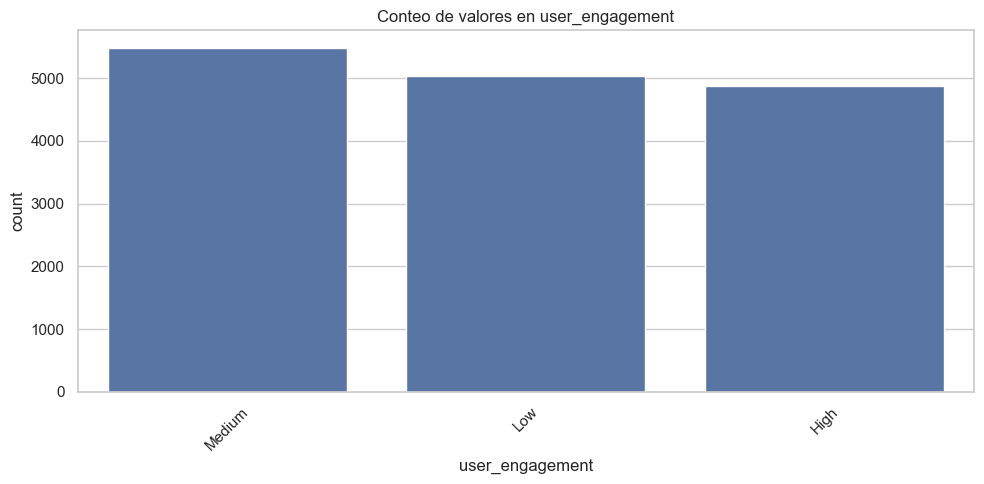

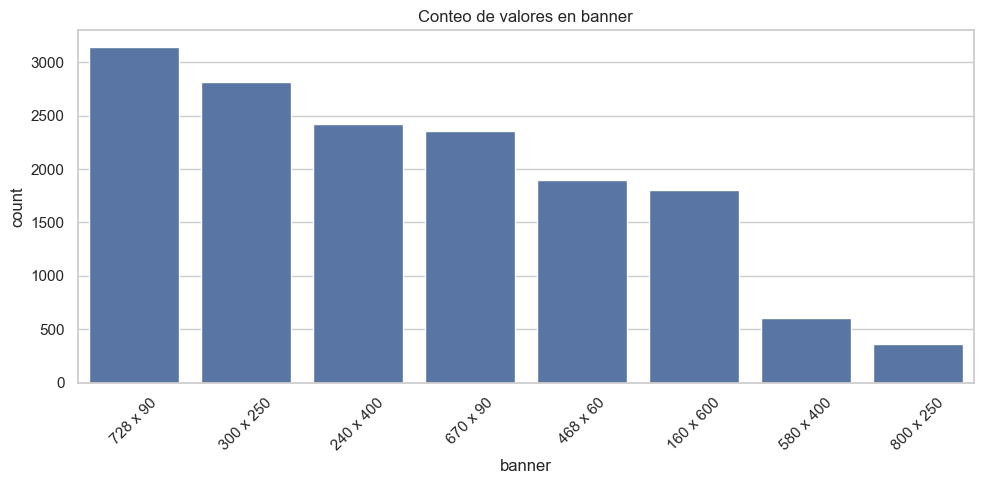

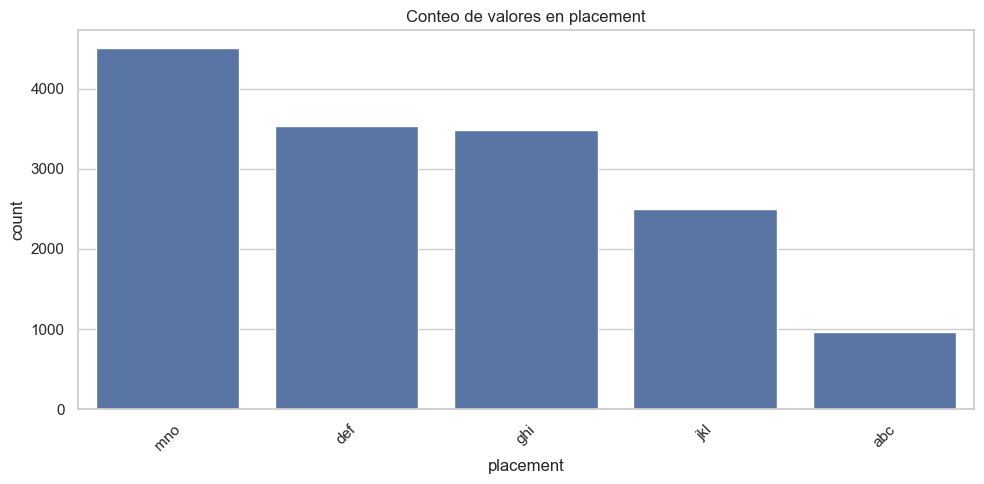

In [17]:
#Valores únicos en columnas categóricas
categoricas = df.select_dtypes(include='object').columns
print(f'Columnas categóricas: {list(categoricas)}\n')

for col in categoricas:
    print(f'--- {col} ({df[col].nunique()} valores únicos) ---')
    print(df[col].value_counts().to_string())
    print()
#Graficar valores únicos en columnas categóricas
for col in categoricas:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Conteo de valores en {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [18]:
#Revisión de columnas de fecha
posibles_fechas = [c for c in df.columns if any(x in c.lower() for x in ['date', 'fecha', 'time', 'year', 'month'])]
print(f'Posibles columnas de fecha: {posibles_fechas}')

for col in posibles_fechas:
    print(df[col].value_counts().head(10).to_string())

Posibles columnas de fecha: ['month']
month
April    6269
May      4705
June     4434


In [19]:
#Detección de outliers en columnas numéricas
numericas = df.select_dtypes(include=[np.number]).columns

print('OUTLIERS POR COLUMNA (método IQR)')
resumen_outliers = []
for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    resumen_outliers.append({'Columna': col, 'Outliers': n_out, '%': round(n_out / len(df) * 100, 2)})

df_out = pd.DataFrame(resumen_outliers)
print(df_out.to_string(index=False))

OUTLIERS POR COLUMNA (método IQR)
                Columna  Outliers     %
                    day         0  0.00
               displays      2257 14.65
                   cost      2515 16.32
                 clicks      2325 15.09
                revenue      2512 16.30
 post_click_conversions      2721 17.66
post_click_sales_amount      2989 19.40
            Unnamed: 12         0  0.00
            Unnamed: 13         0  0.00


In [21]:
#Variación entre grupos por canal
#Identifica automáticamente columnas numéricas y categóricas
#para ver dónde hay variación real entre grupos

cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
cols_cat = df.select_dtypes(include='object').columns.tolist()

print('VARIACIÓN ENTRE GRUPOS (coeficiente de variación)')
for col_num in cols_num[:6]:  #primeras 6 métricas
    print(f'{col_num}')
    for col_cat in cols_cat[:5]:  #primeras 5 dimensiones
        stats = df.groupby(col_cat)[col_num].mean()
        if stats.mean() != 0:
            cv = (stats.std() / stats.mean() * 100)
            print(f'  por {col_cat}: variación = {cv:.2f}%')
    print()

VARIACIÓN ENTRE GRUPOS (coeficiente de variación)
day
  por month: variación = 2.91%
  por campaign_number: variación = 0.25%
  por user_engagement: variación = 0.21%
  por banner: variación = 2.90%
  por placement: variación = 0.32%

displays
  por month: variación = 36.05%
  por campaign_number: variación = 56.59%
  por user_engagement: variación = 79.69%
  por banner: variación = 85.38%
  por placement: variación = 106.04%

cost
  por month: variación = 33.56%
  por campaign_number: variación = 93.27%
  por user_engagement: variación = 135.93%
  por banner: variación = 87.40%
  por placement: variación = 110.15%

clicks
  por month: variación = 69.88%
  por campaign_number: variación = 101.02%
  por user_engagement: variación = 79.16%
  por banner: variación = 107.10%
  por placement: variación = 115.56%

revenue
  por month: variación = 61.14%
  por campaign_number: variación = 85.44%
  por user_engagement: variación = 120.84%
  por banner: variación = 114.57%
  por placement: vari